# LIBRARY

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [3]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8381, 17)
y shape : (8381,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1566, 2.0: 936, 3.0: 85}


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [5]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {0.0: 4055, 1.0: 1096, 2.0: 655, 3.0: 60}


In [6]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Random forest

In [7]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [8]:
def plot_roc_curve(X_test, y_test, best_model):    
# Predizioni probabilistiche
    y_score = best_model.predict_proba(X_test)

    # Classi
    classes = np.unique(y_test)

    # Binarizzazione delle etichette
    y_test_bin = label_binarize(y_test, classes=classes)

    # Plot
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Classe {class_name} (AUC = {roc_auc:.3f})'
        )

    # Linea casuale
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(loc='lower right')

    plt.show()

In [9]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         ['gini', 'entropy'],
}

In [10]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced_subsample',  # fisso, sempre garantito
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=StratifiedKFold(                     # fondamentale con classi sbilanciate
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='f1_macro',                     # equo per classi sbilanciate
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [5, 7, 10, 15],
                                        'max_features': ['log2', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1_macro', verbose=1)


── Best hyperparameters found ──────────────────────────
  n_estimators        : 200
  min_samples_split   : 10
  min_samples_leaf    : 2
  max_features        : log2
  max_depth           : 10
  criterion           : gini

  F1-macro (CV): 0.3235

── Classification Report (Test set) ───────────────────
              precision    recall  f1-score   support

         0.0       0.76      0.71      0.73      1739
         1.0       0.25      0.22      0.23       470
         2.0       0.20      0.33      0.25       281
         3.0       0.00      0.00      0.00        25

    accuracy                           0.57      2515
   macro avg       0.30      0.32      0.31      2515
weighted avg       0.59      0.57      0.58      2515

  F1-macro (Test):  0.3052
  F1-macro (CV):    0.3235
  Delta CV→Test:    -0.0182  (ok)


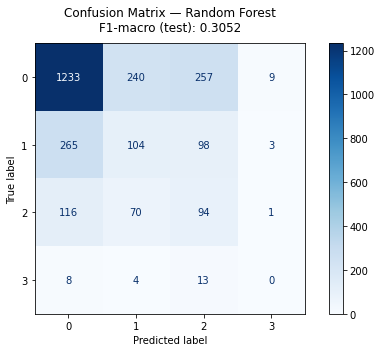

In [11]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")

# ── Modello migliore ─────────────────────────────────────────────────────────
best_model = random_search.best_estimator_



# ── Previsioni sul test set ──────────────────────────────────────────────────
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)

# ── Metriche ─────────────────────────────────────────────────────────────────
print("\n── Classification Report (Test set) ───────────────────")
print(classification_report(y_test, y_pred))

f1_test  = f1_score(y_test, y_pred, average='macro')
f1_cv    = random_search.best_score_
delta    = f1_test - f1_cv

print(f"  F1-macro (Test):  {f1_test:.4f}")
print(f"  F1-macro (CV):    {f1_cv:.4f}")
print(f"  Delta CV→Test:    {delta:+.4f}  "
      f"{'(ok)' if abs(delta) < 0.05 else '(attenzione: possibile overfitting)'}")

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(
    ax=ax, colorbar=True, cmap='Blues'
)
ax.set_title(
    f"Confusion Matrix — Random Forest\nF1-macro (test): {f1_test:.4f}",
    fontsize=12, pad=12,
)
plt.tight_layout()
plt.show()

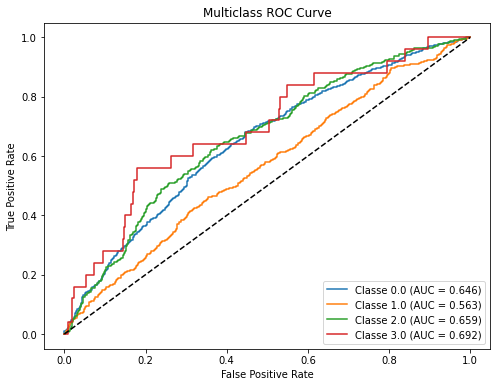

In [12]:
plot_roc_curve(X_test, y_test, best_model)

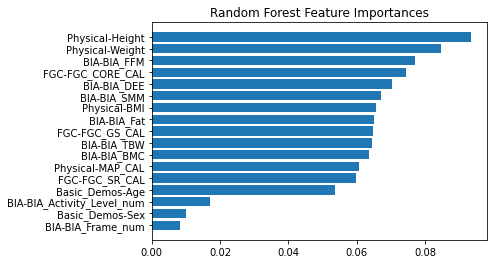

In [13]:
feature_imp(best_model, attributes)

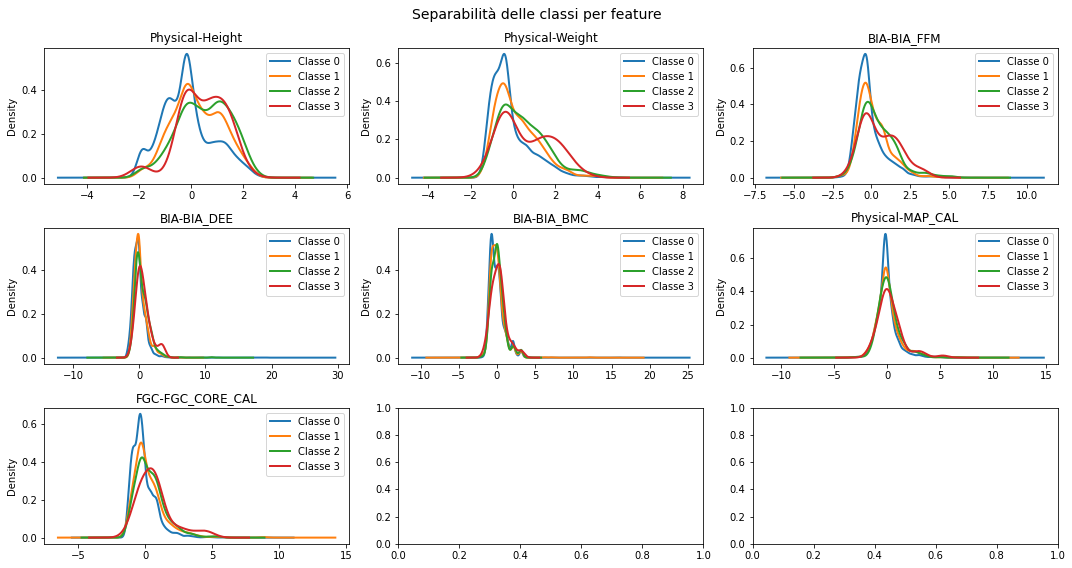

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Converte in DataFrame se necessario
X_train_df = pd.DataFrame(X_train, columns=attributes)

top_features = [
    'Physical-Height',
    'Physical-Weight',
    'BIA-BIA_FFM',
    'BIA-BIA_DEE',
    'BIA-BIA_BMC',
    'Physical-MAP_CAL',
    "FGC-FGC_CORE_CAL"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):

    for cls in [0, 1, 2, 3]:

        subset = X_train_df[y_train == cls][feat]

        subset.plot(
            kind='kde',
            ax=axes[i],
            label=f'Classe {cls}',
            linewidth=2
        )

    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle("Separabilità delle classi per feature", fontsize=14)
plt.tight_layout()
plt.show()

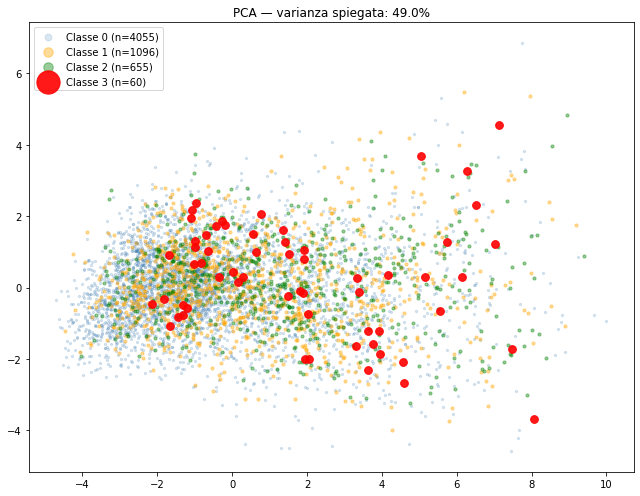

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(9, 7))
colors = {0: 'steelblue', 1: 'orange', 2: 'green', 3: 'red'}
sizes  = {0: 5, 1: 10, 2: 10, 3: 60}   # classe 3 più visibile
alphas = {0: 0.2, 1: 0.4, 2: 0.4, 3: 0.9}

for cls in [0, 1, 2, 3]:
    mask = y_train == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cls], label=f'Classe {cls} (n={mask.sum()})',
               s=sizes[cls], alpha=alphas[cls])

ax.set_title(f"PCA — varianza spiegata: {pca.explained_variance_ratio_.sum():.1%}")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()